In [3]:
import time
import statistics

def at_most_k_distinct(arr, k):
    if k == 0:
        return 0

    frequency = {}
    left = 0
    count = 0

    for right in range(len(arr)):
        frequency[arr[right]] = frequency.get(arr[right], 0) + 1

        while len(frequency) > k:
            frequency[arr[left]] -= 1

            if frequency[arr[left]] == 0:
                del frequency[arr[left]]

            left += 1

        count += right - left + 1

    return count


def exactly_k_distinct(arr, k):
    return at_most_k_distinct(arr, k) - at_most_k_distinct(arr, k - 1)


sizes = list(range(100, 10001, 500))
times = []
runs = 5

for n in sizes:
    # Fixed deterministic input
    arr = [(i * 37) % 20 for i in range(n)]
    k = 5

    measurements = []

    for _ in range(runs):
        start = time.perf_counter_ns()
        exactly_k_distinct(arr, k)
        end = time.perf_counter_ns()

        measurements.append(end - start)

    times.append(statistics.median(measurements))

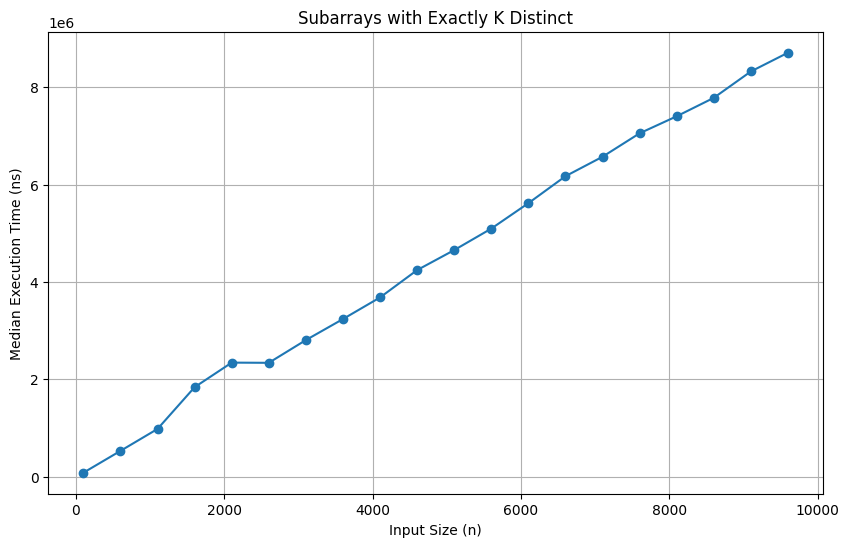

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(sizes, times, marker='o')
plt.title("Subarrays with Exactly K Distinct")
plt.xlabel("Input Size (n)")
plt.ylabel("Median Execution Time (ns)")
plt.grid(True)
plt.show()